In [1]:
!pip install tensorflow opencv-python pandas numpy matplotlib seaborn scikit-learn

In [2]:
import os

print(len(os.listdir('/content')))

2


In [3]:
from google.colab import files

uploaded = files.upload()

Saving HAM10000_metadata.csv to HAM10000_metadata.csv


In [4]:
import pandas as pd

metadata = pd.read_csv("HAM10000_metadata.csv")

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
print(metadata.shape)

metadata['dx'].value_counts()

(10015, 7)


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [55]:
from google.colab import files

uploaded = files.upload()

Saving hmnist_28_28_RGB.csv to hmnist_28_28_RGB.csv


In [56]:
import pandas as pd

data = pd.read_csv("hmnist_28_28_RGB.csv")

print(data.shape)

data.head()

(10015, 2353)


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [57]:
import numpy as np

X = data.drop("label", axis=1)

y = data["label"]

print(X.shape)
print(y.shape)

(10015, 2352)
(10015,)


In [58]:
X = np.array(X)

X = X.reshape(-1, 28, 28, 3)

X = X / 255.0

print(X.shape)

(10015, 28, 28, 3)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8012, 28, 28, 3)
(2003, 28, 28, 3)


In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,3)
    )
)

model.add(MaxPooling2D((2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(7, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,223 (879.78 KB)

 Trainable params: 225,223 (879.78 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.6705 - loss: 0.9835 - val_accuracy: 0.6750 - val_loss: 0.9301
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6858 - loss: 0.8760 - val_accuracy: 0.6970 - val_loss: 0.8616
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.7034 - loss: 0.8229 - val_accuracy: 0.6860 - val_loss: 0.8947
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.7122 - loss: 0.7756 - val_accuracy: 0.6880 - val_loss: 0.8398
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.7233 - loss: 0.7477 - val_accuracy: 0.7184 - val_loss: 0.7945
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.7343 - loss: 0.7093 - val_accuracy: 0.7289 - val_loss: 0.7549
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7470 - loss: 0.6879 - val_accuracy: 0.7314 - val_loss: 0.7400
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.7541 - loss: 0.6636 - val

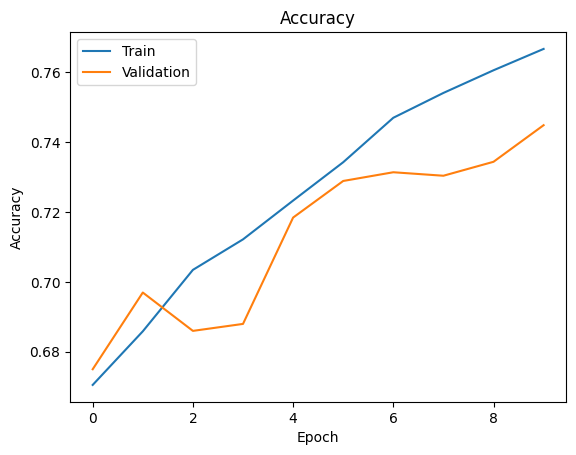

In [62]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [63]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7449 - loss: 0.7080
Accuracy: 0.7448827028274536


In [64]:
model.save("skin_disease_model.h5")

In [65]:
from google.colab import files

uploaded = files.upload()

Saving ISIC_0024306.jpg to ISIC_0024306 (1).jpg


In [66]:
import cv2
import numpy as np

img_name = list(uploaded.keys())[0]

img = cv2.imread(img_name)

img = cv2.resize(img,(28,28))

img = img / 255.0

img = np.expand_dims(img,axis=0)

prediction = model.predict(img)

predicted_class = np.argmax(prediction)

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Predicted Class: 4


In [67]:
confidence = np.max(prediction)

if confidence > 0.90:
    severity = "High"
elif confidence > 0.70:
    severity = "Medium"
else:
    severity = "Low"

print("Severity Level:", severity)

Severity Level: Low


In [68]:
disease_names = {
    0:"Actinic Keratosis",
    1:"Basal Cell Carcinoma",
    2:"Benign Keratosis",
    3:"Dermatofibroma",
    4:"Melanoma",
    5:"Nevus",
    6:"Vascular Lesion"
}

print(
    "Disease:",
    disease_names[predicted_class]
)

Disease: Melanoma


In [69]:
recommendations = {

"Actinic Keratosis":
"Use sunscreen and consult dermatologist",

"Basal Cell Carcinoma":
"Immediate dermatologist consultation",

"Benign Keratosis":
"Regular skin monitoring",

"Dermatofibroma":
"Usually harmless, monitor changes",

"Melanoma":
"Urgent dermatologist consultation",

"Nevus":
"Routine observation",

"Vascular Lesion":
"Consult specialist if symptoms worsen"
}

disease = disease_names[predicted_class]

print(
    recommendations[disease]
)

Urgent dermatologist consultation


In [70]:
high_risk = [
    "Melanoma",
    "Basal Cell Carcinoma"
]

if disease in high_risk:
    print(
        "⚠ Doctor Referral Recommended"
    )
else:
    print(
        "Routine Monitoring Recommended"
    )

⚠ Doctor Referral Recommended


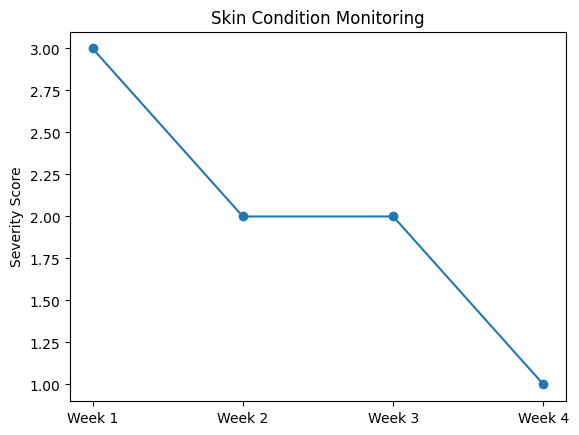

In [71]:
timeline = {
    "Week 1":3,
    "Week 2":2,
    "Week 3":2,
    "Week 4":1
}

import matplotlib.pyplot as plt

plt.plot(
    list(timeline.keys()),
    list(timeline.values()),
    marker="o"
)

plt.title(
    "Skin Condition Monitoring"
)

plt.ylabel(
    "Severity Score"
)

plt.show()

In [72]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
[[  24   18   10    0   16    0    1]
 [   5   59   11    0   16    2    0]
 [  10   15  110    0   88    0    5]
 [   3   12    3    1    9    0    0]
 [   4   13   47    0 1265    2    7]
 [   1    6    1    0    6    7    0]
 [  12    5   42    0  141    0   26]]


In [73]:
model.save(
    "SkinDiseaseDetectionModel.h5"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


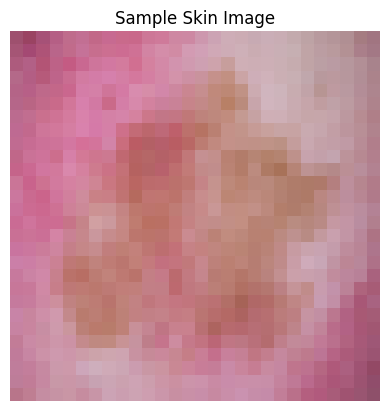

In [74]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0])
plt.title("Sample Skin Image")
plt.axis("off")
plt.show()

In [75]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

print(
    classification_report(
        y_test,
        y_pred
    )
)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
              precision    recall  f1-score   support

           0       0.41      0.35      0.38        69
           1       0.46      0.63      0.53        93
           2       0.49      0.48      0.49       228
           3       1.00      0.04      0.07        28
           4       0.82      0.95      0.88      1338
           5       0.64      0.33      0.44        21
           6       0.67      0.12      0.20       226

    accuracy                           0.74      2003
   macro avg       0.64      0.41      0.43      2003
weighted avg       0.74      0.74      0.71      2003



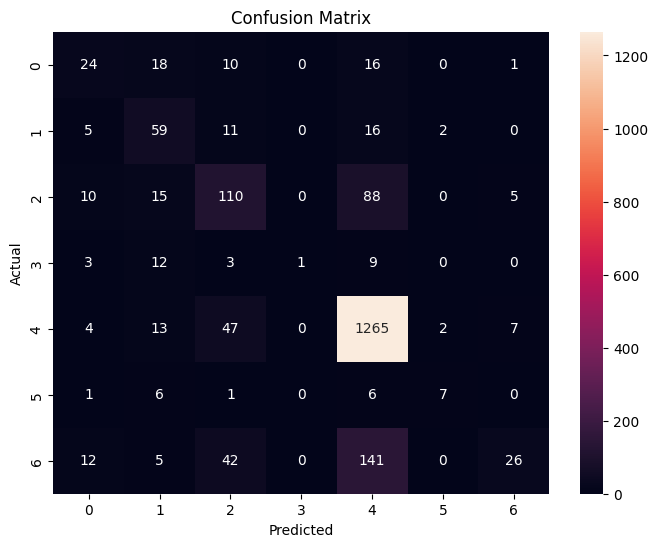

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

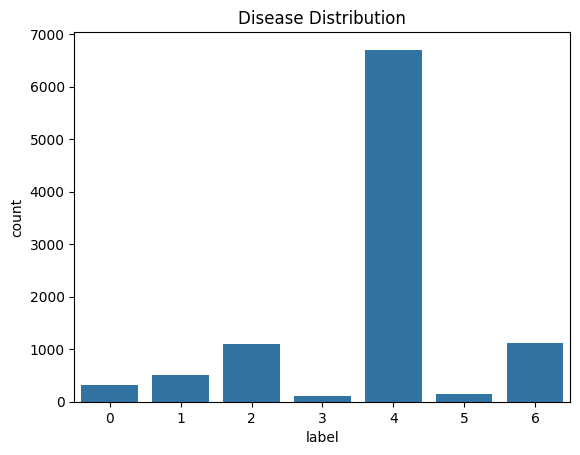

In [77]:
import seaborn as sns

sns.countplot(x=y)

plt.title(
    "Disease Distribution"
)

plt.show()

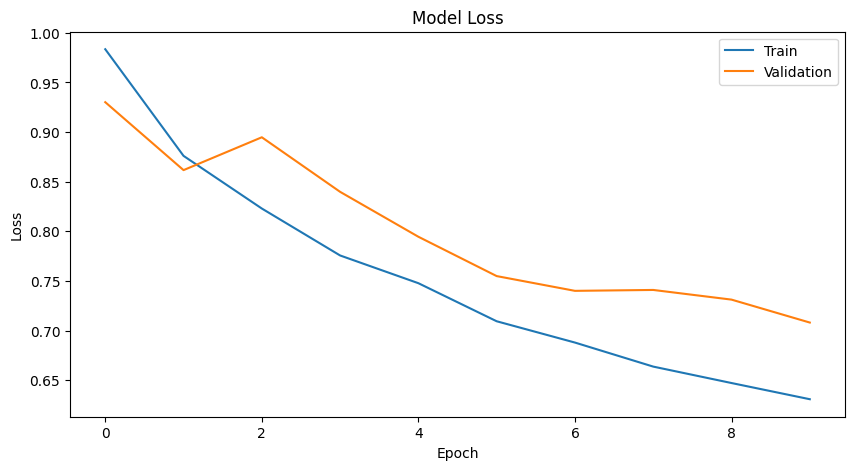

In [78]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.title(
    "Model Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(
    ["Train","Validation"]
)

plt.show()

In [79]:
from google.colab import files

files.download(
    "SkinDiseaseDetectionModel.h5"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
if disease == "Melanoma":

    risk = "Very High"

elif disease == "Basal Cell Carcinoma":

    risk = "High"

else:

    risk = "Low"

print(
    "Risk Level:",
    risk
)

Risk Level: Very High


In [81]:
report = {
    "Disease": disease,
    "Severity": severity,
    "Risk": risk
}

print(report)

{'Disease': 'Melanoma', 'Severity': 'Low', 'Risk': 'Very High'}


In [82]:
print("""
Future Scope

1. Mobile App Development
2. Real-Time Monitoring
3. Doctor Appointment Integration
4. Cloud Database Storage
5. AI-Based Treatment Suggestions
6. Telemedicine Support
""")


Future Scope

1. Mobile App Development
2. Real-Time Monitoring
3. Doctor Appointment Integration
4. Cloud Database Storage
5. AI-Based Treatment Suggestions
6. Telemedicine Support



In [83]:
print("""
SKIN DISEASE DETECTION AND MONITORING APP

Features Implemented:

✓ Skin Disease Detection
✓ CNN Deep Learning Model
✓ Severity Analysis
✓ Risk Assessment
✓ Treatment Recommendation
✓ Doctor Referral
✓ Monitoring Timeline
✓ Confusion Matrix
✓ Classification Report

Project Successfully Completed.
""")


SKIN DISEASE DETECTION AND MONITORING APP

Features Implemented:

✓ Skin Disease Detection
✓ CNN Deep Learning Model
✓ Severity Analysis
✓ Risk Assessment
✓ Treatment Recommendation
✓ Doctor Referral
✓ Monitoring Timeline
✓ Confusion Matrix
✓ Classification Report

Project Successfully Completed.

